# Titulo: Semivariograma.
## Diplomado: Geoestadística y análisis espacial
## SciData
## Instructor: Alexis Adonai Morales Alberto


In [1]:
# Instalación de paquetes

!pip install pyproj scikit-gstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 709.1/709.1 kB 8.5 MB/s eta 0:00:00


In [2]:
# Modulos

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive
from skgstat import Variogram

## Mapa temático para identificar el fenómeno

In [3]:
# Configuración de google drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Ruta completa del archivo

ruta_mapa = '/content/drive/MyDrive/SciData/GEOAES_25/Mapas/México_ent_22/00ent'
ruta_data = '/content/drive/MyDrive/SciData/GEOAES_25/Bases/Pobreza_rel_2024.csv'

In [5]:
# Cargar mapa

Mapa = gpd.read_file(ruta_mapa + '.shp')
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [6]:
# Cargar datos de pobreza 2024

Data = pd.read_csv(ruta_data)

Data.head(1)

,CVE_ENT,ENTIDAD,Pobreza
0,1,Aguascalientes,17.068482


In [7]:
# Verificar columnas

Mapa['CVE_ENT'] = pd.to_numeric(Mapa['CVE_ENT'], errors = 'coerce')

Mapa[['CVE_ENT', 'NOMGEO']].dtypes

,0
CVE_ENT,int64
NOMGEO,object


In [8]:
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [9]:
Data[['CVE_ENT', 'ENTIDAD']].dtypes

,0
CVE_ENT,int64
ENTIDAD,object


In [10]:
# Combinar datos con el mapa

Mapa = Mapa.merge(
    Data,
    left_on= ["CVE_ENT","NOMGEO"],
    right_on=["CVE_ENT","ENTIDAD"],
    how = 'left'
)

In [11]:
Mapa.head(1)

Output hidden; open in https://colab.research.google.com to view.

In [12]:
Mapa.dtypes

,0
CVEGEO,object
CVE_ENT,int64
NOMGEO,object
geometry,geometry
ENTIDAD,object
Pobreza,float64


In [13]:
Mapa = Mapa.rename(columns={'Pobreza ': 'Pobreza'}) # Aportación de Jorge Calvillo

## 1. Cálculo de centroides

In [14]:
Mapa['centroid'] = Mapa.geometry.centroid

coords = np.array([
    (point.x, point.y) for point in Mapa['centroid']
])

values = Mapa['Pobreza'].values

## 2. Cálcular semivariograma empírico con distintos estimadores

Al usar **sckit-gstat**, tiene multiples argumetos para los distintos estimadores que hay en el cálculo o estimación del semivariograma.

Los argumento o estimadores disponibles son:

1. **matheron**: Se refiere a la estimación clásica (sensible a los outliers).

2. **crissie**: Se refiere a la estimación robusta.

3. **dowd**: Se refifere a la estimación altamente robusta.

4. **geton**: Se refiere a la estimación robusta moderna.

2.1 Comparación de los estimadores

In [16]:
# Cálculo de los estimadores del semivariograma

estimadores = ["matheron", "cressie", "dowd", "genton"]

variogramas = {}

for est in estimadores:
  V = Variogram(
      coords,
      values,
      estimator = est,
      model = 'spherical',
      maxlag = 800000, #800 km aprox
      n_lags = 10,
      normalize = False
  )

  variogramas[est] = V

In [17]:
variogramas

{'matheron': < spherical Semivariogram fitted to 10 bins >,
 'cressie': < spherical Semivariogram fitted to 10 bins >,
 'dowd': < spherical Semivariogram fitted to 10 bins >,
 'genton': < spherical Semivariogram fitted to 10 bins >}

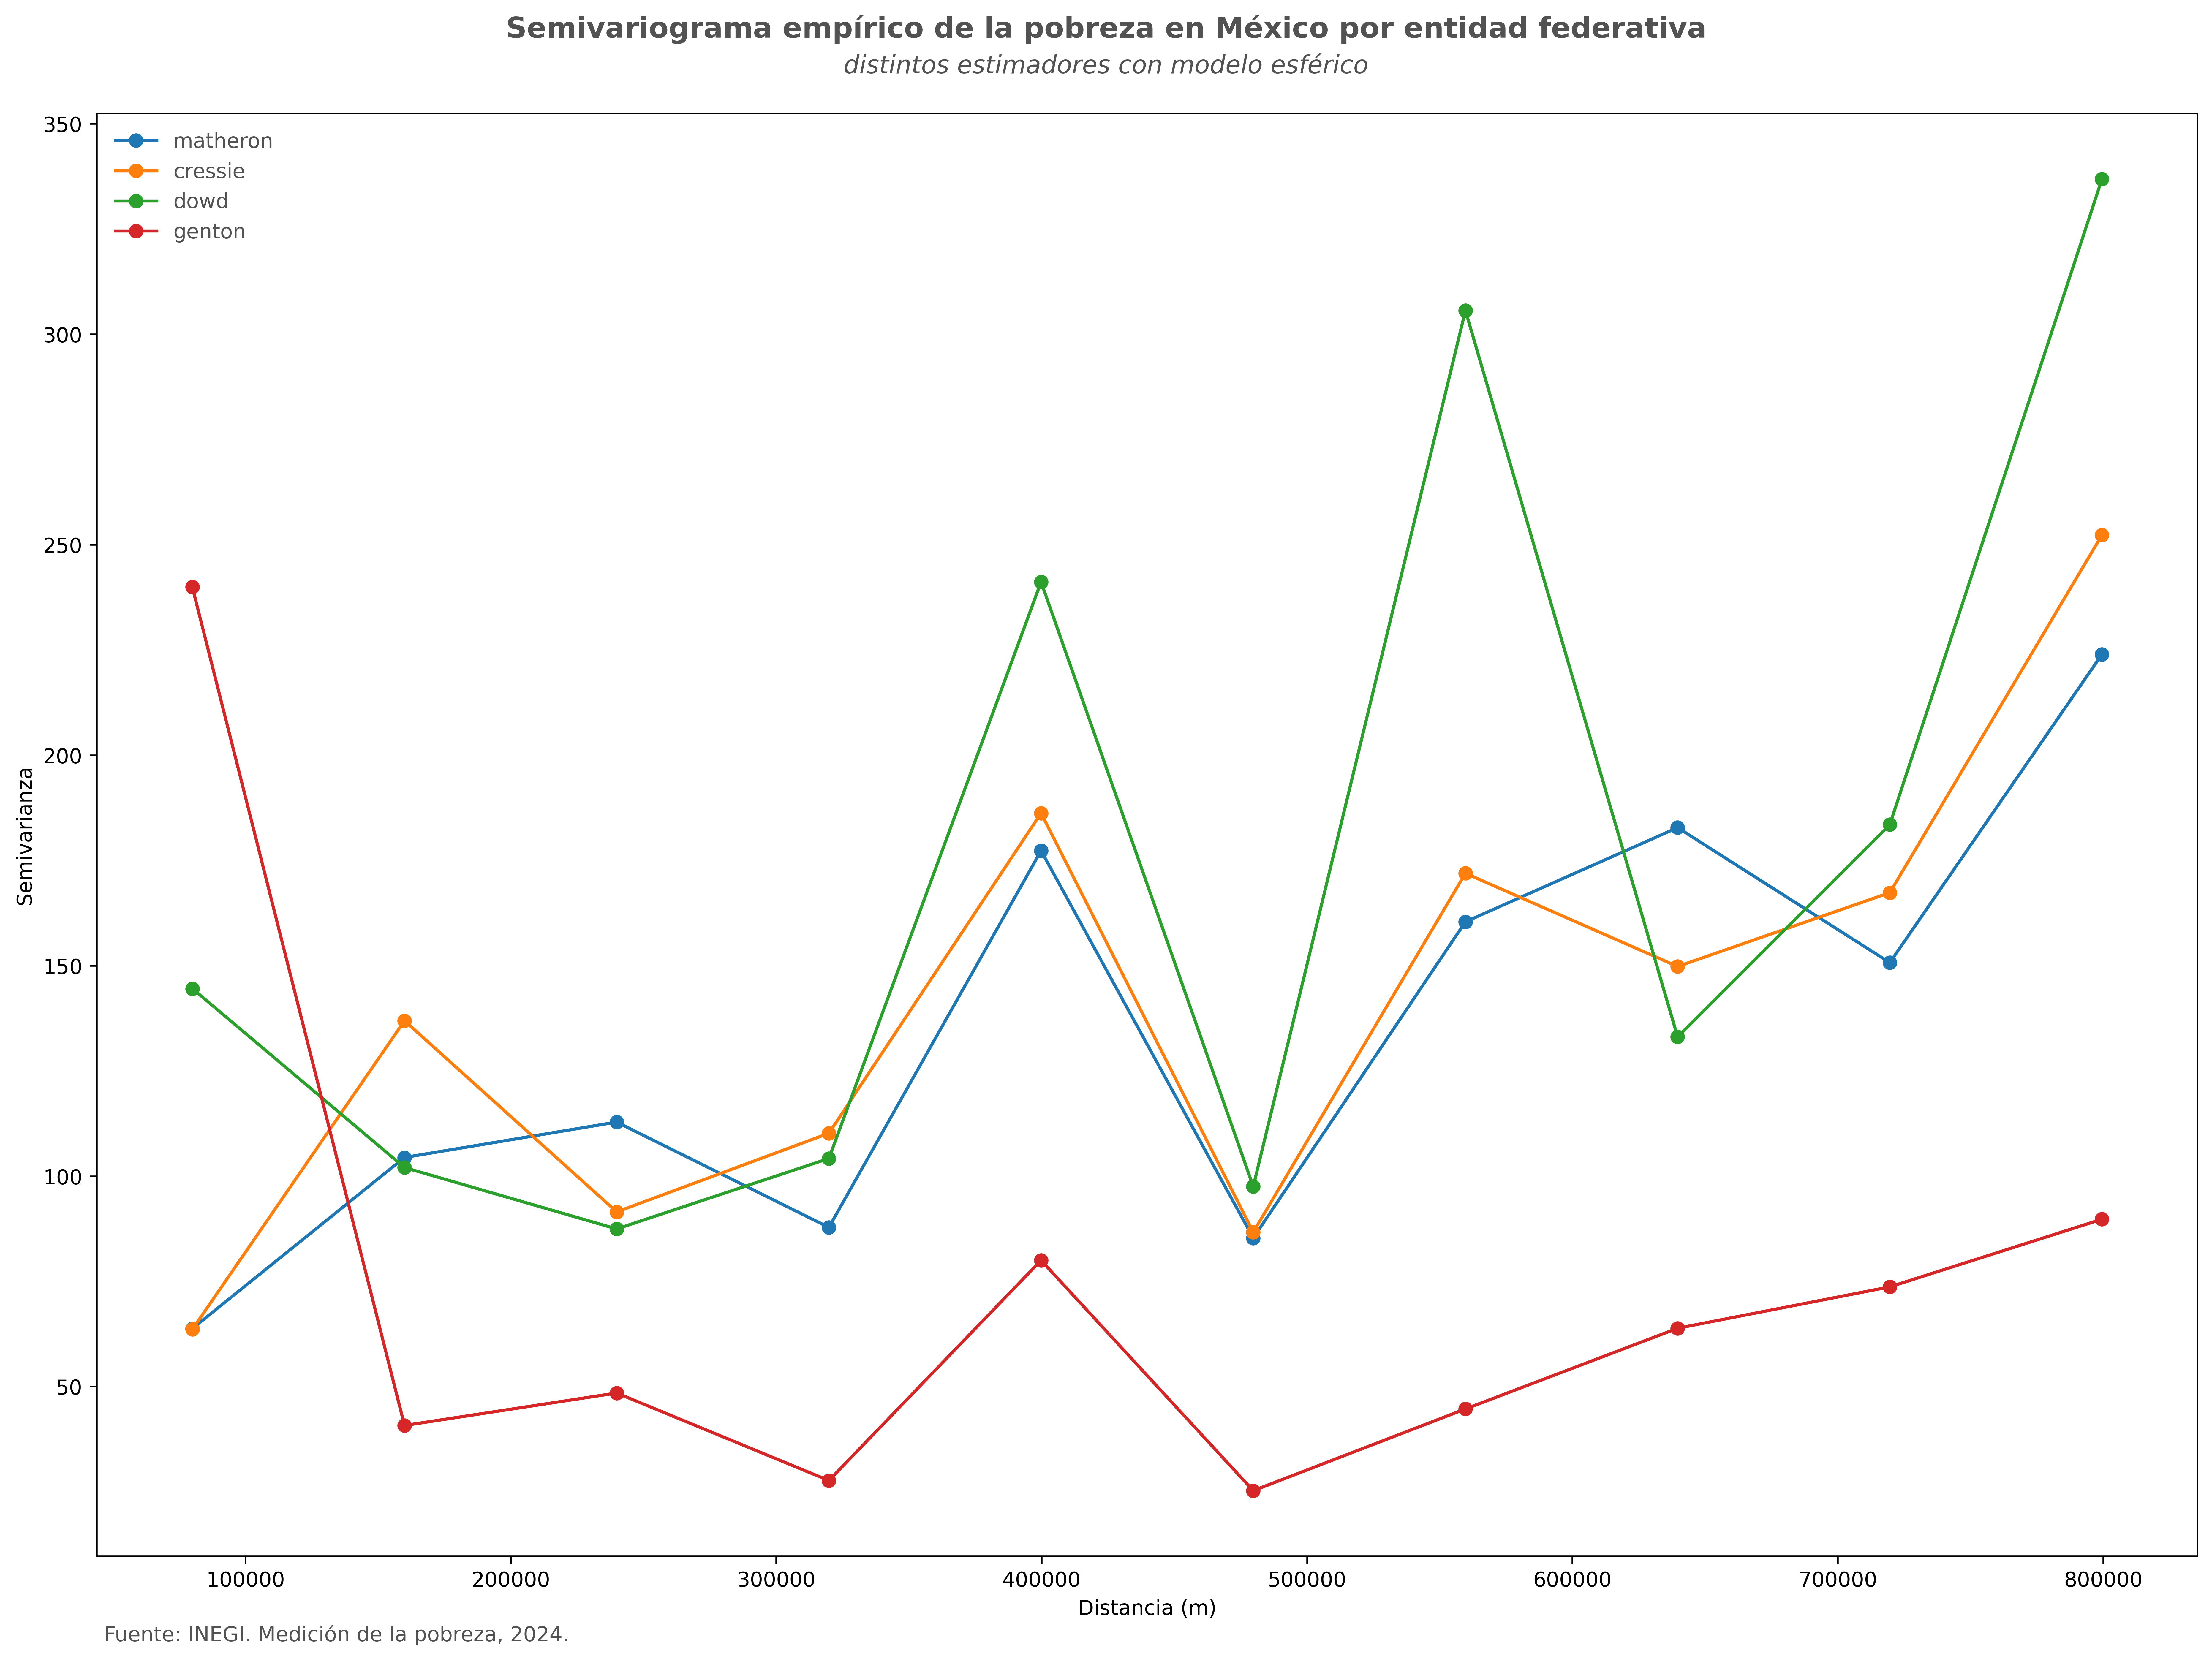

In [24]:
plt.figure(figsize=(15,12), dpi = 500)
for est, V in variogramas.items():
  plt.plot(V.bins, V.experimental, marker = "o", label = est)

plt.xlabel("Distancia (m)")
plt.ylabel("Semivarianza")
plt.legend()
plt.figtext(0.5, 0.95, "Semivariograma empírico de la pobreza en México por entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.5, 0.93, "distintos estimadores con modelo esférico",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: INEGI. Medición de la pobreza, 2024.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
leg = ax.get_legend()
for text in leg.get_texts():
  text.set_color('#525252')
if leg is not None:
  leg.get_frame().set_linewidth(0)
  leg.get_frame().set_edgecolor("none")
plt.grid(False)
plt.tight_layout(rect = [0,0.05,1,0.92])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Semivariograma.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')


2.2 Comparativa con modelos

In [25]:
# Cálculo de semivariograma con diferentes modelos según el estimador cressie

models = ['spherical', 'exponential', "gaussian", "matern"]

variogramas_modelo = {}

for model in models:
  V = Variogram(
      coords,
      values,
      estimator='cressie',
      model = model,
      maxlag = 800000,
      n_lags = 10
  )

  variogramas_modelo[model] = V

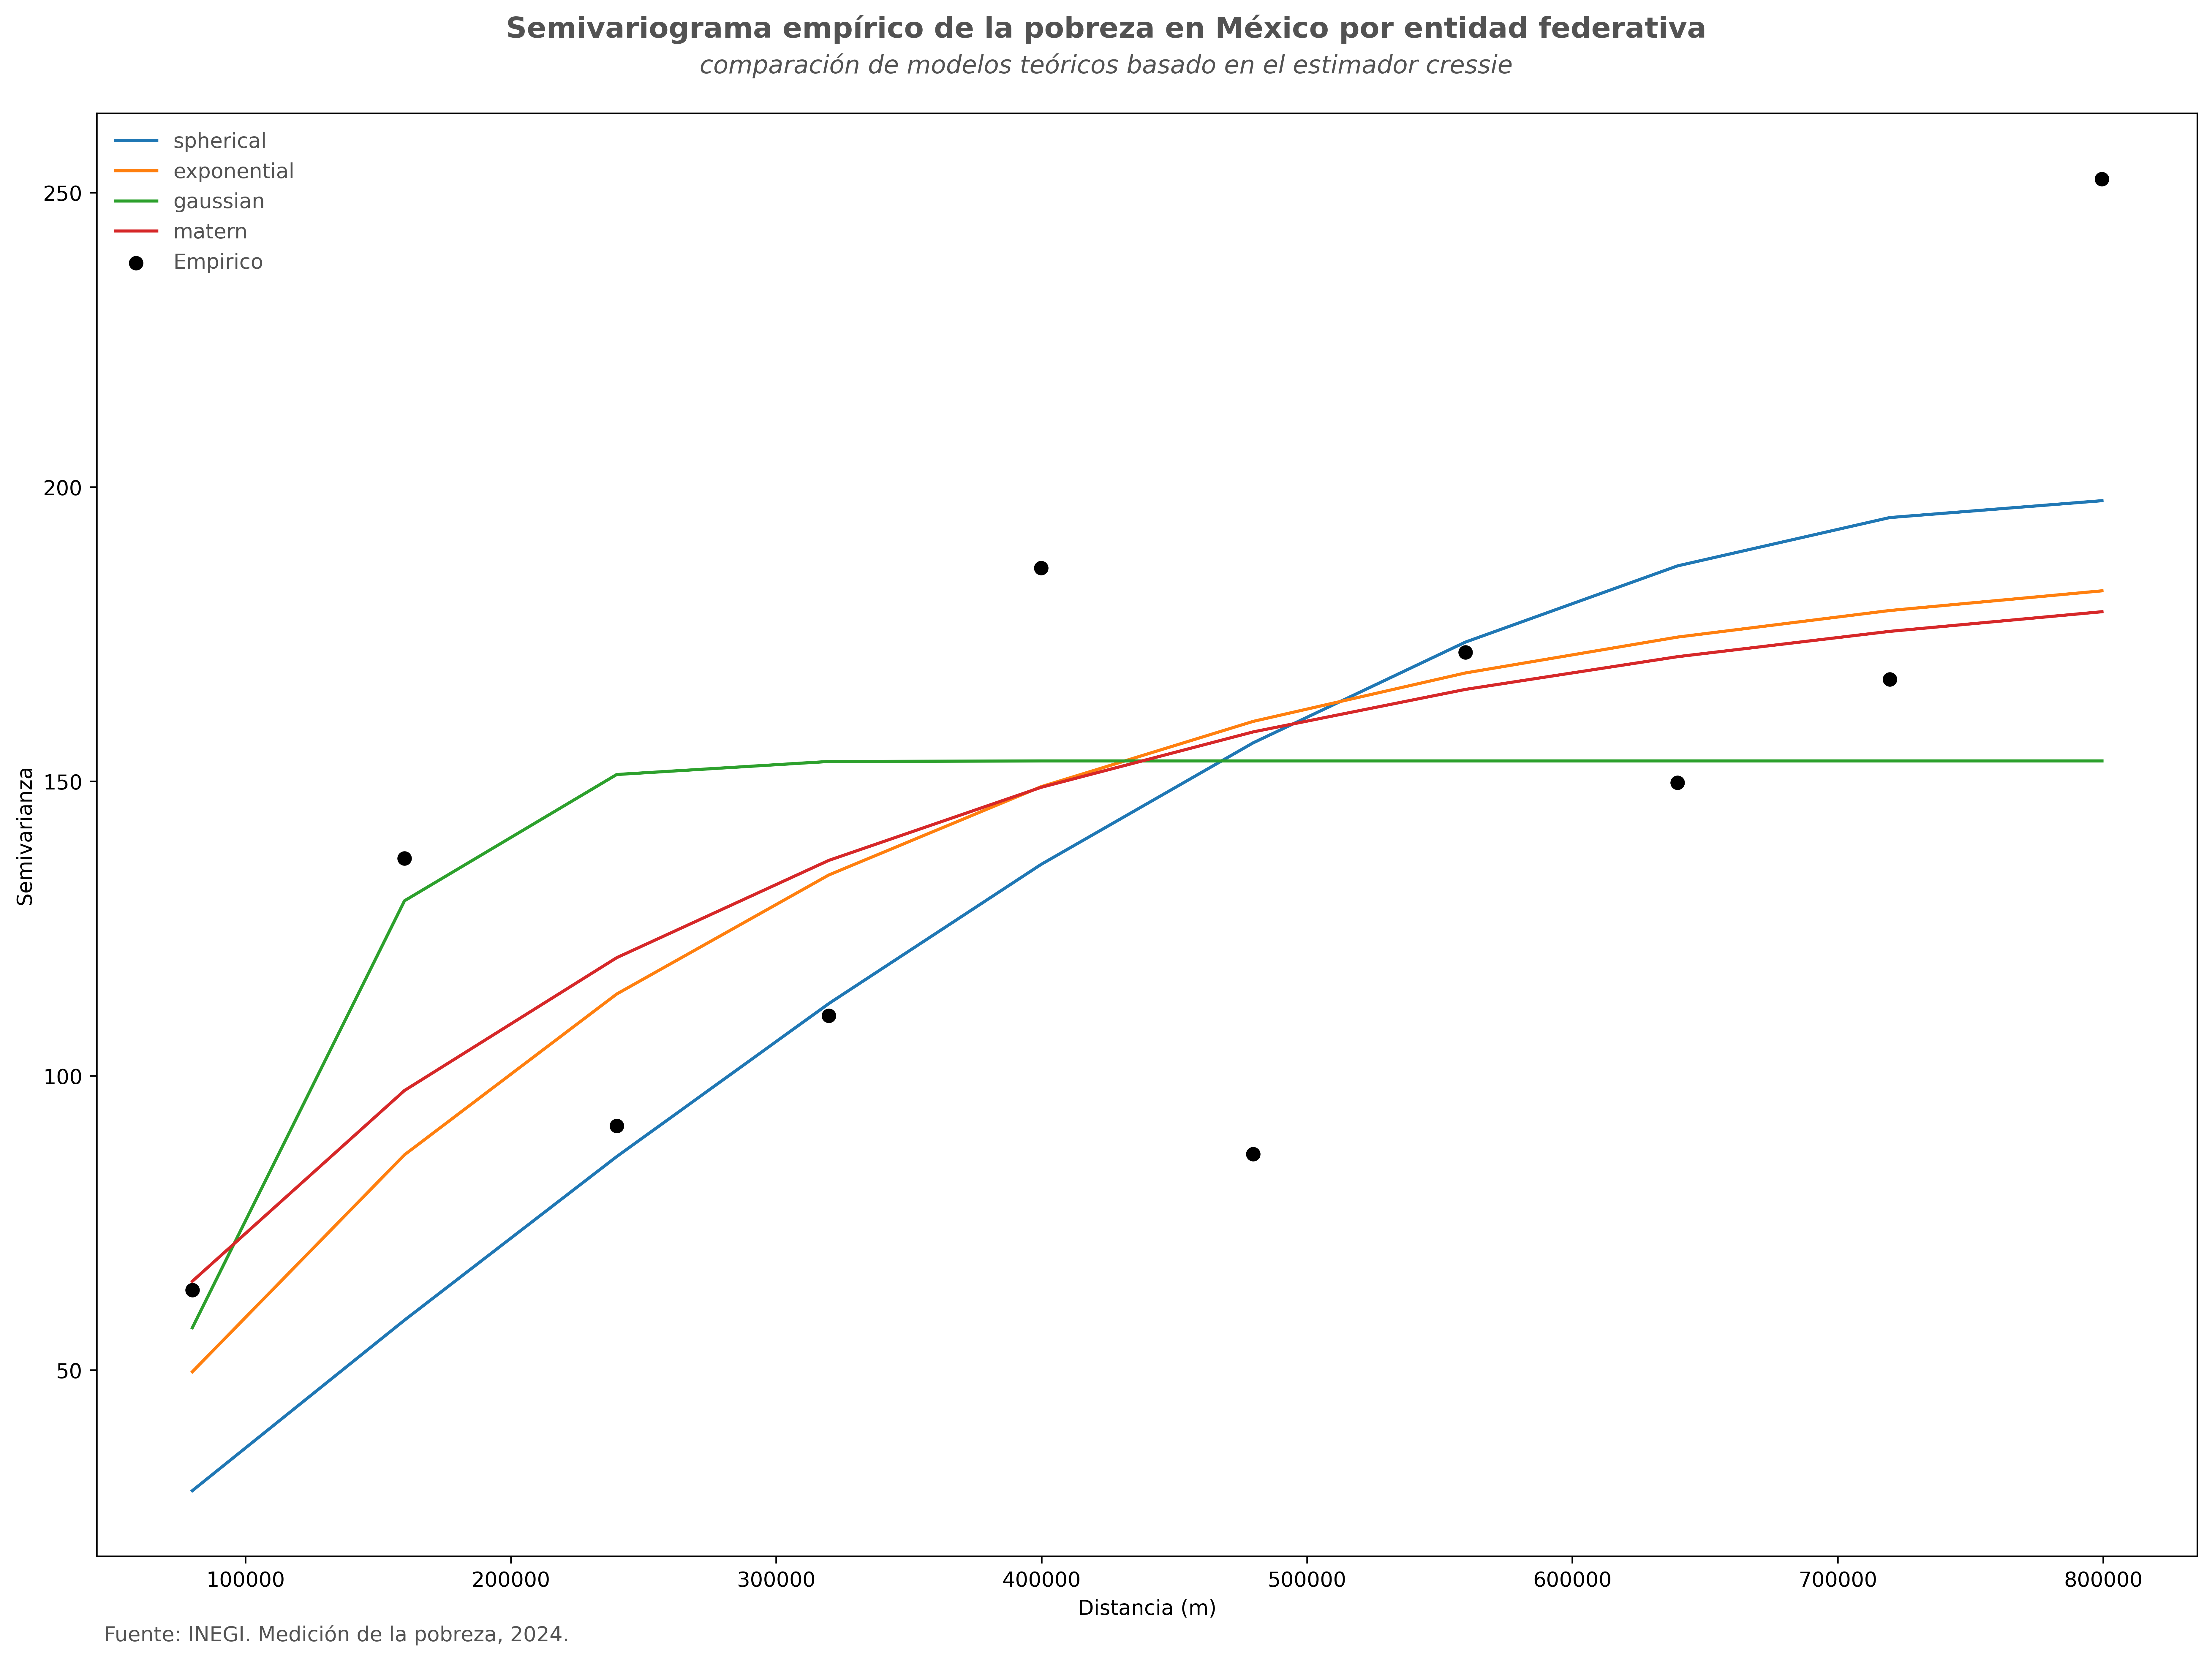

In [26]:
# Gráfico comparativo

plt.figure(figsize=(15,12), dpi = 500)

for model, V in variogramas_modelo.items():
  plt.plot(V.bins, V.fitted_model(V.bins), label = model)

plt.scatter(
    variogramas_modelo['spherical'].bins,
    variogramas_modelo['spherical'].experimental,
    color = "black",
    label = "Empirico"
)

plt.xlabel("Distancia (m)")
plt.ylabel("Semivarianza")
plt.legend()
plt.figtext(0.5, 0.95, "Semivariograma empírico de la pobreza en México por entidad federativa",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.5, 0.93, "comparación de modelos teóricos basado en el estimador cressie",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: INEGI. Medición de la pobreza, 2024.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
leg = ax.get_legend()
for text in leg.get_texts():
  text.set_color('#525252')
if leg is not None:
  leg.get_frame().set_linewidth(0)
  leg.get_frame().set_edgecolor("none")
plt.grid(False)
plt.tight_layout(rect = [0,0.05,1,0.92])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Semivariograma_modelos.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')



2.3 Comparativa modelo-estimador

In [28]:
# Cálculo del semivariograma

models = ['spherical', 'exponential', "gaussian", "matern"]
estimadores = ["matheron", "cressie", "dowd", "genton"]

results = []

for est in estimadores:
  for model in models:
    try:
      V = Variogram(
        coords,
        values,
        estimator = est,
        model = model,
        n_lags = 10,
        maxlag = 800000,
        normalize = False
      )

      nugget, sill, rang = V.parameters

      results.append({
          "estimador": est,
          "modelo": model,
          "nugget": nugget,
          "sill": sill,
          "range": rang,
          "rss": V.rss
      })

    except Exception as e:
      results.append({
          "estimador": est,
          "modelo": model,
          "nugget": None,
          "sill": None,
          "range": None,
          "rss": None
      })

Resultados = pd.DataFrame(results)
Resultados


,estimador,modelo,nugget,sill,range,rss
0,matheron,spherical,799538.242106,189.502379,0.0,13844.527592
1,matheron,exponential,799538.242107,183.606184,0.0,11328.743624
2,matheron,gaussian,341896.890101,153.488825,0.0,16573.173269
3,matheron,matern,NaN,NaN,NaN,NaN
4,cressie,spherical,799538.242107,197.694733,0.0,19853.232519
5,cressie,exponential,799538.242107,191.941210,0.0,16233.787325
6,cressie,gaussian,234110.583208,153.492417,0.0,21369.086951
7,cressie,matern,NaN,NaN,NaN,NaN
8,dowd,spherical,799538.242107,243.460249,0.0,58346.552574
9,dowd,exponential,799538.242107,234.835240,0.0,57051.524698


In [29]:
# Seleccionar mejor modelo con estimador

Resultados.sort_values('rss')

,estimador,modelo,nugget,sill,range,rss
1,matheron,exponential,799538.242107,183.606184,0.0,11328.743624
0,matheron,spherical,799538.242106,189.502379,0.0,13844.527592
5,cressie,exponential,799538.242107,191.941210,0.0,16233.787325
2,matheron,gaussian,341896.890101,153.488825,0.0,16573.173269
4,cressie,spherical,799538.242107,197.694733,0.0,19853.232519
6,cressie,gaussian,234110.583208,153.492417,0.0,21369.086951
14,genton,gaussian,3525.775812,73.431156,0.0,35056.078381
12,genton,spherical,58863.255244,73.431156,0.0,35056.078381
13,genton,exponential,1544.642836,73.431156,0.0,35056.078381
9,dowd,exponential,799538.242107,234.835240,0.0,57051.524698


In [30]:
# Mejor combinación global

Mejor = Resultados.loc[Resultados['rss'].idxmin()]
Mejor

,1
estimador,matheron
modelo,exponential
nugget,799538.242107
sill,183.606184
range,0.0
rss,11328.743624


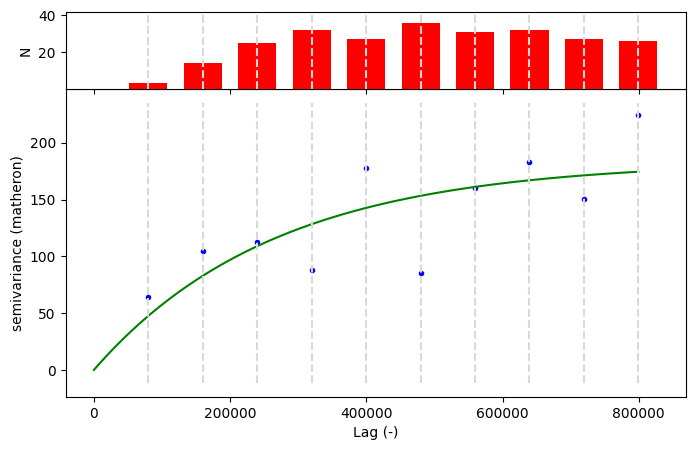

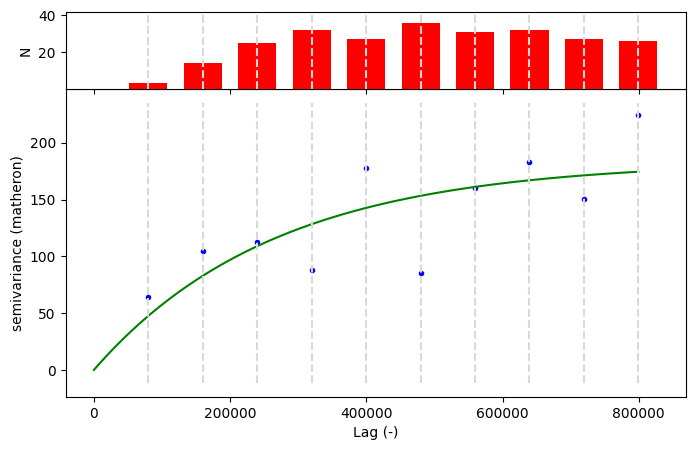

In [33]:
# Visualización de la mejor combinación

mejor_variograma = Variogram(
    coords,
    values,
    estimator = Mejor['estimador'],
    model = Mejor['modelo'],
    n_lags = 10,
    maxlag = 800000
)

mejor_variograma.plot()


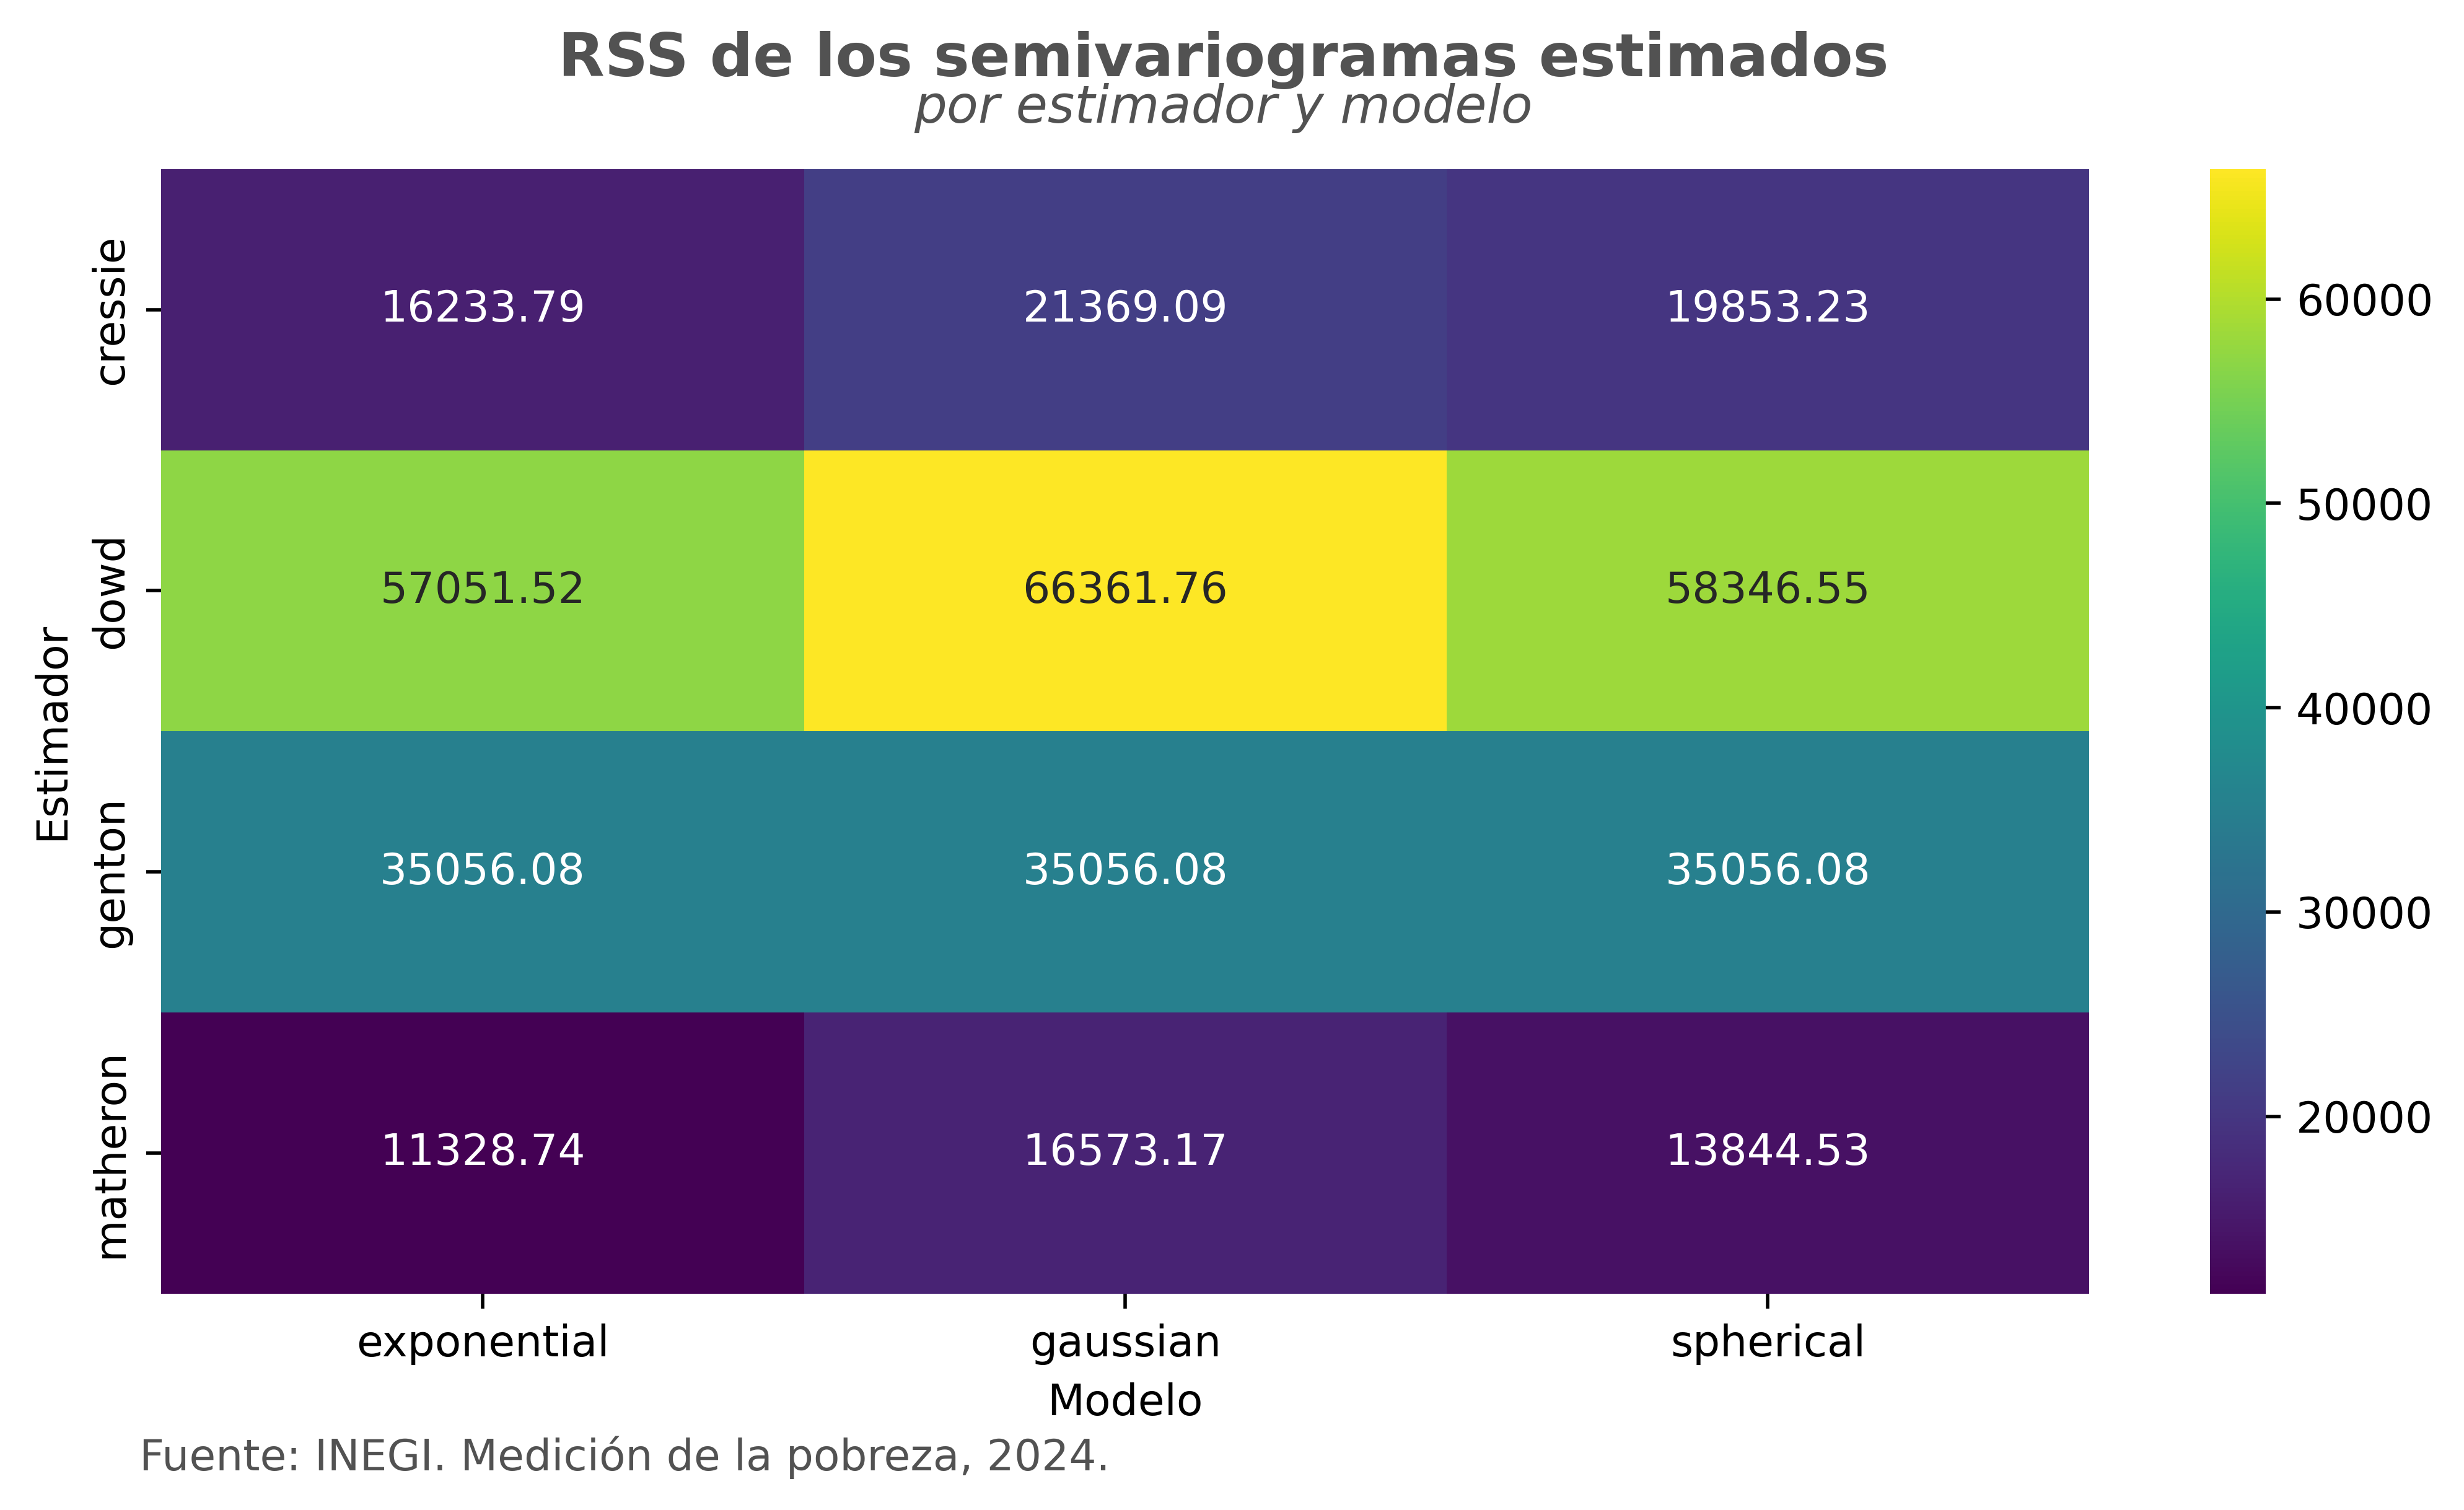

In [37]:
# Mapa de calor para comparar modelos-estimadores

pivot = Resultados.loc[Resultados['modelo'] != "matern"].pivot(
    index = "estimador",
    columns = "modelo",
    values = "rss"
)

fig, ax = plt.subplots(1,1, figsize = (10,5), dpi = 500)
sns.heatmap(pivot, annot = True, fmt=".2f", cmap = 'viridis', ax=ax)
plt.xlabel("Modelo")
plt.ylabel("Estimador")
plt.figtext(0.4, 0.95, "RSS de los semivariogramas estimados",
            fontweight = 'bold',
            color = "#525252",
            ha = 'center',
            fontsize = 14) # Titulo
plt.figtext(0.4, 0.92, "por estimador y modelo",
            style = "italic",
            color = "#525252",
            ha = 'center',
            fontsize = 12) # Subtitulo
plt.figtext(0.05, 0.05, "Fuente: INEGI. Medición de la pobreza, 2024.",
            color = "#525252",
            fontsize = 10) # Pie de gráfico
ax = plt.gca()
plt.tight_layout(rect = [0,0.05,0.85,0.92])
ruta_guardado = '/content/drive/MyDrive/SciData/GEOAES_25/Salidas/Hetmap_variogramas_modelo_est.png'
plt.savefig(ruta_guardado, dpi = 500, bbox_inches = 'tight', facecolor = 'white')
